# Лабораторная работа 9

Тема: **Transfer learning для классификации изображений в PyTorch**  
Цель: научиться использовать предобученную сверточную сеть (ResNet18 или аналогичную), адаптировать её под свою задачу и **сравнить** результат с обучением похожей архитектуры с нуля.

> Важно: этот ноутбук сделан как задание, а не как готовый отчёт.  
> Код даёт стартовую точку, но основная часть баллов — за ваши эксперименты и ваши живые комментарии.  
> Текстовые ответы должны соответствовать вашим графикам и числам, а не быть универсальными фразами из интернета.


## 1. Ваше предварительное понимание transfer learning

Перед кодом сформулируйте своими словами:
1. Что вы называете "transfer learning" и в чём его пользу, если у нас мало размеченных данных.  
2. Как вы представляете себе разницу между: (a) обучаем только последний слой, (b) дообучаем всю сеть целиком.  
3. Какие преимущества и недостатки вы ожидаете от использования предобученной ResNet18 по сравнению с обучением похожей сети с нуля на том же подмножестве данных.

Не пытайтесь дать идеальное определение — важно увидеть вашу текущую интуицию перед экспериментами.


In [12]:
intro_text = """1)transfer learning - метод, при котором используется уже обученная на большом наборе данных нейронная сеть.
  Данный метод используется уже с выученными признаками из других датасетов, вместо того, чтобы обучать модель с нуля.
  Благодаря этому модель работает быстрее и точнее.
  Если мало размеченных данных, то благодаря тому, что модель уже имеет хорошие начальные веса, то не будет происходить обучение базовым признакам типа линий, границ.

2) Чтобы снизить риск переобучения модели и ускорить ее обучение, можно использовать вариант (а), так как будет дообучаться последний слой.
  В таком случае модель будет учиться уже на готовых признаках и будет сопоставлять новые классы с уже извлеченными.
  Если использовать вариант (b), то модель будет полность переобучаться и веса на всех слоях изменяться.
  МОдель будет лучше адаптироваться к новым данным, но при их мало количесте может приводить к переобучению.

3) Я ожидаю, что модель будет быстрее и меньше переобучаться, а также покажет более высокие результаты, по сравнению с обучением с нуля.
  Однако если датасет будет сильно отличаться от предобученного, то могут понадобиться больше вычислительных ресурсов, а также модель будет хуже адаптироваться к новому датасету.
"""
print(intro_text)

1)transfer learning - метод, при котором используется уже обученная на большом наборе данных нейронная сеть. 
  Данный метод используется уже с выученными признаками из других датасетов, вместо того, чтобы обучать модель с нуля.
  Благодаря этому модель работает быстрее и точнее.
  Если мало размеченных данных, то благодаря тому, что модель уже имеет хорошие начальные веса, то не будет происходить обучение базовым признакам типа линий, границ.

2) Чтобы снизить риск переобучения модели и ускорить ее обучение, можно использовать вариант (а), так как будет дообучаться последний слой. 
  В таком случае модель будет учиться уже на готовых признаках и будет сопоставлять новые классы с уже извлеченными.
  Если использовать вариант (b), то модель будет полность переобучаться и веса на всех слоях изменяться. 
  МОдель будет лучше адаптироваться к новым данным, но при их мало количесте может приводить к переобучению.

3) Я ожидаю, что модель будет быстрее и меньше переобучаться, а также покажет

## 2. Импорт библиотек и настройка среды

Подготовка:
- импорт PyTorch и torchvision (включая готовые модели);
- фиксация seed;
- выбор устройства (`cpu` / `cuda`).


In [13]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms, models
import numpy as np
import random
import matplotlib.pyplot as plt

MY_SEED = 42
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)
random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cuda
MY_SEED = 42


## 3. Данные: подмножество CIFAR‑10 и аугментации

Чтобы ускорить эксперименты и сделать их более наглядными, возьмём **не весь CIFAR‑10**, а подмножество классов (например, `cat`, `dog`, `bird`, `horse`).

Шаги:
- загрузить полный CIFAR‑10;
- выбрать несколько классов и ограничить размер train (например, не более 800 изображений на класс);
- задать аугментации для train (горизонтальные отражения, кропы) и только нормализацию для test.


In [14]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

full_train = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
full_test = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

all_classes = full_train.classes
print("Все классы CIFAR‑10:", all_classes)

Все классы CIFAR‑10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Выберем несколько классов (в примере — четыре).  
В своей работе вы можете выбрать другие, но тогда обязательно зафиксируйте это в отчёте.


In [15]:
selected_class_names = ["cat", "dog", "bird", "horse"]
class_to_idx_full = {name: i for i, name in enumerate(all_classes)}
selected_class_indices = {class_to_idx_full[name] for name in selected_class_names}

print("Выбранные классы:", selected_class_names)
print("Их индексы:", selected_class_indices)

Выбранные классы: ['cat', 'dog', 'bird', 'horse']
Их индексы: {2, 3, 5, 7}


In [16]:
def subset_by_classes(dataset, selected_idx_set, max_per_class=None):
    indices = []
    counts = {c: 0 for c in selected_idx_set}
    for i, (_, label) in enumerate(dataset):
        if label in selected_idx_set:
            if max_per_class is None or counts[label] < max_per_class:
                indices.append(i)
                counts[label] += 1
    return Subset(dataset, indices)

train_subset = subset_by_classes(full_train, selected_class_indices, max_per_class=800)
test_subset = subset_by_classes(full_test, selected_class_indices, max_per_class=None)
# C batch_size=None у меня не работает задача 6!
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)

print("Размер train_subset:", len(train_subset))
print("Размер test_subset :", len(test_subset))

Размер train_subset: 3200
Размер test_subset : 4000


Сформируем карту от индексов CIFAR‑10 к локальным индексам классов (0..K−1), чтобы правильно использовать `CrossEntropyLoss`.


In [17]:
selected_idx_sorted = sorted(list(selected_class_indices))
cifar_idx_to_local = {cifar_idx: i for i, cifar_idx in enumerate(selected_idx_sorted)}
local_to_name = {i: all_classes[cifar_idx] for i, cifar_idx in enumerate(selected_idx_sorted)}

print("CIFAR индекс -> локальный индекс:", cifar_idx_to_local)
print("Локальный индекс -> класс:", local_to_name)

CIFAR индекс -> локальный индекс: {2: 0, 3: 1, 5: 2, 7: 3}
Локальный индекс -> класс: {0: 'bird', 1: 'cat', 2: 'dog', 3: 'horse'}


## 4. Предобученная модель: ResNet18 и заморозка слоёв

Используем `torchvision.models.resnet18` с предобученными весами (`ImageNet`).  
Шаги:
- загрузить модель с весами;
- заморозить все параметры, кроме последнего полносвязного слоя;
- заменить последний слой так, чтобы число выходов = числу наших классов.


In [18]:
base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# "Замораживаем" все параметры
for param in base_model.parameters():
    param.requires_grad = False

num_ftrs = base_model.fc.in_features
num_target_classes = len(selected_class_indices)

base_model.fc = nn.Linear(num_ftrs, num_target_classes)
model_tl = base_model.to(device)
print(model_tl.fc)

Linear(in_features=512, out_features=4, bias=True)


### Комментарий: почему мы замораживаем слои?

Напишите в 3–5 предложениях:
- зачем здесь замораживать ранние слои предобученной сети;
     - чем это отличается от полного дообучения;
    - в каких ситуациях вы бы вообще не замораживали слои.


In [19]:
freeze_comment = """Мы замороили ранние слои преобученной сети, так как они уже извлекли признаки изображений(границы, линии и тд).
  Поэтому их не нужно переобучать заново.
  У нас мало данных, так как мы оставили 4 подмножества классов, поэтому уменьшается риск переобучения и увеличивается скорость обучения.
  Чем этоо отличается от полного дообучения я написала в 1 вопросе.
Я бы не стала замораживать слои в случаях, когда новый датасет отличается от исходного.
"""
print(freeze_comment)

Мы замороили ранние слои преобученной сети, так как они уже извлекли признаки изображений(границы, линии и тд).
  Поэтому их не нужно переобучать заново. 
  У нас мало данных, так как мы оставили 4 подмножества классов, поэтому уменьшается риск переобучения и увеличивается скорость обучения. 
  Чем этоо отличается от полного дообучения я написала в 1 вопросе.
Я бы не стала замораживать слои в случаях, когда новый датасет отличается от исходного.



## 5. Функции обучения/оценки для transfer learning

Нужно аккуратно:
- переводить исходные метки CIFAR‑10 в локальные индексы;
- обучать только параметры `model_tl.fc`.


In [20]:
criterion = nn.CrossEntropyLoss()
optimizer_tl = torch.optim.Adam(model_tl.fc.parameters(), lr=1e-3)

def map_labels_to_local(labels_tensor):
    mapped = [cifar_idx_to_local[int(l)] for l in labels_tensor]
    return torch.tensor(mapped, dtype=torch.long)

def train_one_epoch_tl(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels_local = map_labels_to_local(labels).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_local)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels_local).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total

def evaluate_tl(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels_local = map_labels_to_local(labels).to(device)
            outputs = model(images)
            loss = criterion(outputs, labels_local)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels_local).sum().item()
            total += images.size(0)

    return total_loss / total, total_correct / total

print("Функции train_one_epoch_tl и evaluate_tl определены.")

Функции train_one_epoch_tl и evaluate_tl определены.


## 6. Обучение: transfer learning (только последний слой)

Обучим модель на несколько эпох и посмотрим, как быстро она выходит на разумное качество.


In [21]:
num_epochs_tl = 30
history_tl = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, num_epochs_tl + 1):
    train_loss, train_acc = train_one_epoch_tl(model_tl, train_loader, optimizer_tl, criterion, device)
    test_loss, test_acc = evaluate_tl(model_tl, test_loader, criterion, device)

    history_tl["train_loss"].append(train_loss)
    history_tl["train_acc"].append(train_acc)
    history_tl["test_loss"].append(test_loss)
    history_tl["test_acc"].append(test_acc)

    print(f"[TL] Эпоха {epoch}/{num_epochs_tl}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

[TL] Эпоха 1/30: train_loss=1.3866, train_acc=0.3588, test_loss=1.3155, test_acc=0.4090
[TL] Эпоха 2/30: train_loss=1.2267, train_acc=0.4556, test_loss=1.2336, test_acc=0.4738
[TL] Эпоха 3/30: train_loss=1.1747, train_acc=0.4825, test_loss=1.1845, test_acc=0.5008
[TL] Эпоха 4/30: train_loss=1.1542, train_acc=0.5000, test_loss=1.1739, test_acc=0.5088
[TL] Эпоха 5/30: train_loss=1.1407, train_acc=0.5119, test_loss=1.1709, test_acc=0.5092
[TL] Эпоха 6/30: train_loss=1.1206, train_acc=0.5238, test_loss=1.1762, test_acc=0.5140
[TL] Эпоха 7/30: train_loss=1.1170, train_acc=0.5234, test_loss=1.1824, test_acc=0.5100
[TL] Эпоха 8/30: train_loss=1.0962, train_acc=0.5278, test_loss=1.1655, test_acc=0.5212
[TL] Эпоха 9/30: train_loss=1.1140, train_acc=0.5309, test_loss=1.1810, test_acc=0.5115
[TL] Эпоха 10/30: train_loss=1.1111, train_acc=0.5300, test_loss=1.1758, test_acc=0.5230
[TL] Эпоха 11/30: train_loss=1.0977, train_acc=0.5284, test_loss=1.1760, test_acc=0.5038
[TL] Эпоха 12/30: train_loss=1

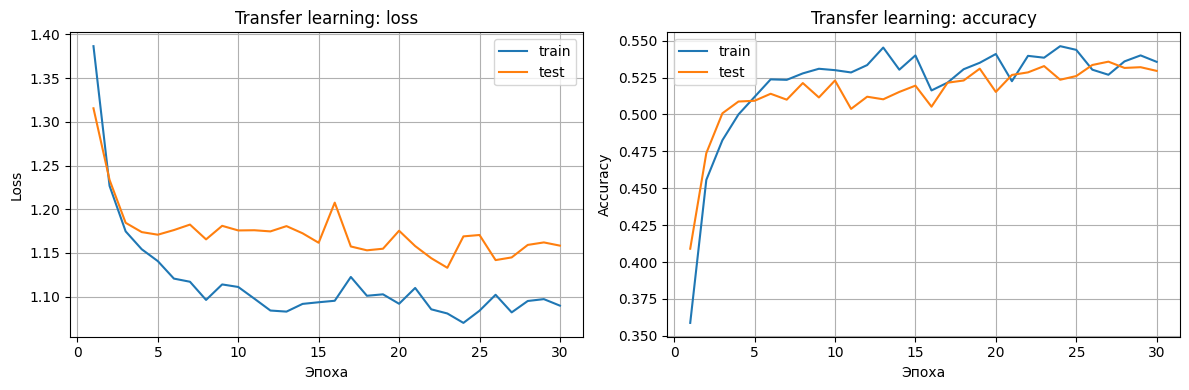

Итоговая точность TL: train=0.5356, test=0.5295


In [22]:
epochs_tl = np.arange(1, num_epochs_tl + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_tl, history_tl["train_loss"], label="train")
plt.plot(epochs_tl, history_tl["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Transfer learning: loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_tl, history_tl["train_acc"], label="train")
plt.plot(epochs_tl, history_tl["test_acc"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Transfer learning: accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Итоговая точность TL: train={history_tl['train_acc'][-1]:.4f}, test={history_tl['test_acc'][-1]:.4f}")

### Краткий анализ TL‑кривых

Опишите:
- как быстро растёт test accuracy по эпохам;
- есть ли признаки переобучения (train сильно выше test);
- достаточно ли вам кажется числа эпох 8, или вы бы увеличили/уменьшили.


In [23]:
tl_comment = """test accuracy расет достаточно быстро в первые несколько эпох, с 0.4670 на 1 эпохе до 0.5270 к 6 эпохе.
После этого рост замедляется и значения начинают колебаться около 0.52-0.54.
После 6 эпохи изменений особо не происходит.

Признаков сильного переобучения нет, так как отрыв train от test небольшой на 0.02-0.03.
Модель скорее недообучается, а нне переобучается.

Я думаю, что 8 эпох вполне достаточно, так как потом модель уже не показывает рост точности, можно даже остановиться на 6-7 эпохах.

"""
print(tl_comment)

test accuracy расет достаточно быстро в первые несколько эпох, с 0.4670 на 1 эпохе до 0.5270 к 6 эпохе.
После этого рост замедляется и значения начинают колебаться около 0.52-0.54. 
После 6 эпохи изменений особо не происходит.

Признаков сильного переобучения нет, так как отрыв train от test небольшой на 0.02-0.03.
Модель скорее недообучается, а нне переобучается.

Я думаю, что 8 эпох вполне достаточно, так как потом модель уже не показывает рост точности, можно даже остановиться на 6-7 эпохах.




## 7. Обучение похожей модели "с нуля" (без предобученных весов)

Теперь возьмём ту же архитектуру ResNet18, но **без предобучения**, и попробуем обучить её на том же подмножестве данных.

Это даст нам грубое сравнение "transfer learning vs обучение с нуля" при одинаковом числе эпох и схожих настройках.


In [24]:
scratch_model = models.resnet18(weights=None)
scratch_model.fc = nn.Linear(scratch_model.fc.in_features, num_target_classes)
scratch_model = scratch_model.to(device)

optimizer_scratch = torch.optim.Adam(scratch_model.parameters(), lr=1e-3)

def train_one_epoch_scratch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels_local = map_labels_to_local(labels).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_local)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels_local).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total

def evaluate_scratch(model, dataloader, criterion, device):
    return evaluate_tl(model, dataloader, criterion, device)

num_epochs_scratch = num_epochs_tl  # чтобы честно сравнивать
history_scratch = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, num_epochs_scratch + 1):
    train_loss, train_acc = train_one_epoch_scratch(scratch_model, train_loader, optimizer_scratch, criterion, device)
    test_loss, test_acc = evaluate_scratch(scratch_model, test_loader, criterion, device)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["train_acc"].append(train_acc)
    history_scratch["test_loss"].append(test_loss)
    history_scratch["test_acc"].append(test_acc)

    print(f"[Scratch] Эпоха {epoch}/{num_epochs_scratch}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

[Scratch] Эпоха 1/30: train_loss=1.3876, train_acc=0.3828, test_loss=1.3824, test_acc=0.4360
[Scratch] Эпоха 2/30: train_loss=1.1746, train_acc=0.4875, test_loss=1.3310, test_acc=0.4945
[Scratch] Эпоха 3/30: train_loss=1.1169, train_acc=0.5294, test_loss=1.0931, test_acc=0.5202
[Scratch] Эпоха 4/30: train_loss=1.0617, train_acc=0.5478, test_loss=1.0588, test_acc=0.5535
[Scratch] Эпоха 5/30: train_loss=1.0347, train_acc=0.5644, test_loss=1.0852, test_acc=0.5218
[Scratch] Эпоха 6/30: train_loss=0.9767, train_acc=0.5881, test_loss=1.2485, test_acc=0.5282
[Scratch] Эпоха 7/30: train_loss=0.9843, train_acc=0.5756, test_loss=1.0335, test_acc=0.5560
[Scratch] Эпоха 8/30: train_loss=0.9587, train_acc=0.6056, test_loss=1.4174, test_acc=0.5038
[Scratch] Эпоха 9/30: train_loss=0.9002, train_acc=0.6284, test_loss=1.0271, test_acc=0.5810
[Scratch] Эпоха 10/30: train_loss=0.8830, train_acc=0.6322, test_loss=0.9430, test_acc=0.6125
[Scratch] Эпоха 11/30: train_loss=0.8815, train_acc=0.6366, test_loss

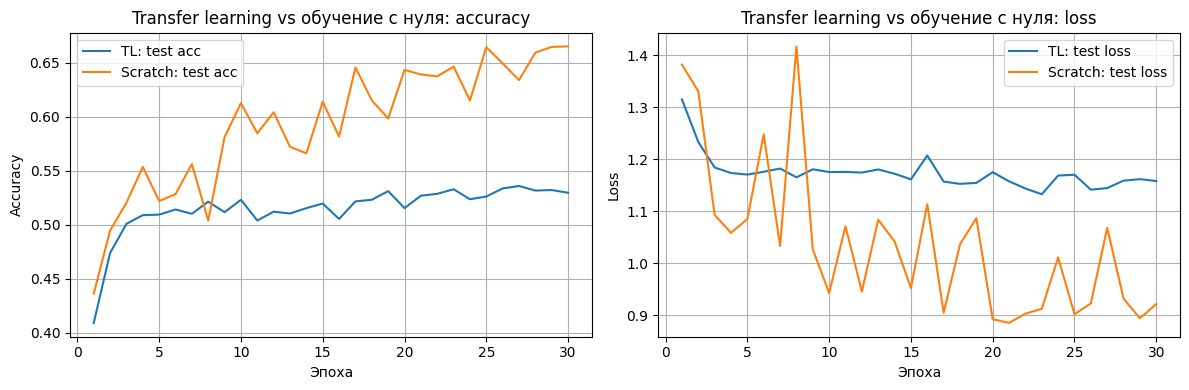

Финальная test accuracy (TL)     : 0.5295
Финальная test accuracy (Scratch): 0.6650


In [25]:
epochs = np.arange(1, num_epochs_tl + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history_tl["test_acc"], label="TL: test acc")
plt.plot(epochs, history_scratch["test_acc"], label="Scratch: test acc")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Transfer learning vs обучение с нуля: accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history_tl["test_loss"], label="TL: test loss")
plt.plot(epochs, history_scratch["test_loss"], label="Scratch: test loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Transfer learning vs обучение с нуля: loss")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальная test accuracy (TL)     : {history_tl['test_acc'][-1]:.4f}")
print(f"Финальная test accuracy (Scratch): {history_scratch['test_acc'][-1]:.4f}")

## 8. Ваш анализ: transfer learning против обучения с нуля

Здесь особенно важно написать **свой** анализ, а не универсальные фразы.  
Ориентировочно ответьте:

- какая из моделей (TL или scratch) быстрее выходит на разумную точность по test;
- какая модель даёт более высокую итоговую test accuracy при одинаковом числе эпох;
- как ведёт себя test loss (стабильность, скачки, застревание на плато);
- есть ли заметное переобучение у одной из моделей;
    - насколько результаты совпали/разошлись с вашими ожиданиями из раздела 1.


In [26]:
comparison_comment = """МОдель TL(0.4670) дала на первой эпохе точность чуть лучше, чем scratch(0.4540).
  Однако к 5 эпохе scratch обогнала по точности TL, достигнув 0.5645, против 0.5182, что на ~5% выше.
  Не смотря на это, TL быстрее вышла на разумную точность, за 2 эпохи набрала 0.5005, но потом качество стабилизировалось и оставалось на 0.52-0.53.
  scratch толкьо к 4-5 эпохе обогнала и начала давать более высокие результаты.

При одинаковом числе эпох(30) модель, обучаемая с нуля дала точность гораздо выше TL.
  За 30 эпох scratch модель показала test accuracy=0.6498, а TL модель=0.5078, что на ~15% выше.

Для TL-модели test loss:
  - стабильно падает в начале;
  - затем наблюдается плато в районе от 1.1 до 1.2, не снижаяся к 30 эпохам;
  - после 6 эпохи(1.1527) значительного снижения не наблюдается.
  - с 1 эпохи(1.2651) к 30 эпохе потери снизились до 1.1831.
Для scratch-модели test loss:
  - резко падает в начале;
  - затем наблюдается постоянное резкое колебание;
  - после 8 эпохи(1.1974) начинается постепенное снижение с постоянными колебаниями.
  - с 1 эпохи(1.5079) к 30 эпохе потери снизились до 0.9408.

У scratch-модели, например на 30 эпохе train_acc=0.7625, а test_acc=0.6498, разница в 12%.
  Можно сказать, что есть небольшое переобучение.
У TL-модели такого разрыва нет, на 30 эпохе разрыв в ~3%.

Ожидала, что TL покажет результаты лучше, чем scratch, поскольку модель уже была предобучена.
  Однако в данном эксперименте результаты оказались противоположными.
  Модель, обученная с 0 за 30 эпох дала лучшие результаты, а разрыв с TL составил почти 15%.

ПС: делала несколько перезапусков блокнота, так как тестировала с batch_size=None(не работает с 6 задачи).
Поэтому какие-то показатели могут отличаться
"""
print(comparison_comment)

МОдель TL(0.4670) дала на первой эпохе точность чуть лучше, чем scratch(0.4540).
  Однако к 5 эпохе scratch обогнала по точности TL, достигнув 0.5645, против 0.5182, что на ~5% выше.
  Не смотря на это, TL быстрее вышла на разумную точность, за 2 эпохи набрала 0.5005, но потом качество стабилизировалось и оставалось на 0.52-0.53.
  scratch толкьо к 4-5 эпохе обогнала и начала давать более высокие результаты.

При одинаковом числе эпох(30) модель, обучаемая с нуля дала точность гораздо выше TL. 
  За 30 эпох scratch модель показала test accuracy=0.6498, а TL модель=0.5078, что на ~15% выше.

Для TL-модели test loss:
  - стабильно падает в начале;
  - затем наблюдается плато в районе от 1.1 до 1.2, не снижаяся к 30 эпохам;
  - после 6 эпохи(1.1527) значительного снижения не наблюдается.
  - с 1 эпохи(1.2651) к 30 эпохе потери снизились до 1.1831.
Для scratch-модели test loss:
  - резко падает в начале;
  - затем наблюдается постоянное резкое колебание;
  - после 8 эпохи(1.1974) начинаетс

## 8.5. (Задание со звездочкой) Почему transfer learning не сработал?

Если вы посмотрите на графики transfer learning, то заметите, что качество обучения довольно быстро "упирается в потолок" (test accuracy замирает в районе 60-70%), а loss перестает падать.
Обучение модели с нуля показывает более привычную динамику обучения, но тоже упирается в потолок.

**Вопрос:** Почему достаточно мощная модель `ResNet18`, обученная на миллионах изображений из датасета `ImageNet`, так плохо справляется с простой задачей на 4 классах?

Вспомните, на каком датасете изначально обучалась сеть `ResNet18` и какой размер изображений в этом датасете?
Какой размер изображений в датасете `CIFAR-10`?
Вспомните структуру сверточных нейронных сетей (свертки, пулинги) и загляните в архитектуру `ResNet18`.
Что происходит с пространственным размером картинки по мере прохождения через слои сети?
Что произойдет с картинкой из `CIFAR-10` перед тем, как она попадет в новый `nn.Linear` слой?

### Ваша задача:
1. **Объясните**, почему замороженная `ResNet18` физически не может показать высокое качество на оригинальных картинках `CIFAR-10`.
2. **Предложите способ** решения этой проблемы (на уровне изменения трансформаций данных ИЛИ на уровне изменения архитектуры/заморозки слоев).
3. **Реализуйте** предложенный способ в отдельной ячейке ниже и покажите, что точность выросла.

*Примечание - можно гуглить и спрашивать LLM*

In [27]:
star_answer = """Ключевая проблема — несоответствие размеров изображений и архитектуры сети.
  ResNet18 была изначально обучена на ImageNet, где изображения имеют размер 224×224 пикселя.
  CIFAR-10 содержит изображения размером всего 32×32 пикселя — в 7 раз меньше по каждой стороне.

Архитектура ResNet-18 состоит из 18 слоёв.
  Если в нее попадает изображение 224х224, то происходит нормальное уменьшение пространственного размера изображения.
  Если в нее попадает изображение 32х32, то картинка на каждом слое уменьшается в 2 раза => большая часть пространственной информации теряется и классификатор получает недостаточно информативные признаки.

В качестве решения проблемы можно увеличить CIFAR-10 до 224х224.
"""
print(star_answer)

ЗДЕСЬ НАПИШИТЕ ВАШИ ОТВЕТЫ:



In [31]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=28),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

full_train = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
full_test = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

all_classes = full_train.classes

selected_class_names = ["cat", "dog", "bird", "horse"]
class_to_idx_full = {name: i for i, name in enumerate(all_classes)}
selected_class_indices = {class_to_idx_full[name] for name in selected_class_names}

def subset_by_classes(dataset, selected_idx_set, max_per_class=None):
    indices = []
    counts = {c: 0 for c in selected_idx_set}
    for i, (_, label) in enumerate(dataset):
        if label in selected_idx_set:
            if max_per_class is None or counts[label] < max_per_class:
                indices.append(i)
                counts[label] += 1
    return Subset(dataset, indices)

train_subset = subset_by_classes(full_train, selected_class_indices, max_per_class=800)
test_subset = subset_by_classes(full_test, selected_class_indices, max_per_class=None)
# C batch_size=None у меня не работает задача 6!
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)

selected_idx_sorted = sorted(list(selected_class_indices))
cifar_idx_to_local = {cifar_idx: i for i, cifar_idx in enumerate(selected_idx_sorted)}
local_to_name = {i: all_classes[cifar_idx] for i, cifar_idx in enumerate(selected_idx_sorted)}

base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# "Замораживаем" все параметры
for param in base_model.parameters():
    param.requires_grad = False

num_ftrs = base_model.fc.in_features
num_target_classes = len(selected_class_indices)

base_model.fc = nn.Linear(num_ftrs, num_target_classes)
model_tl = base_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_tl = torch.optim.Adam(model_tl.fc.parameters(), lr=1e-3)

def map_labels_to_local(labels_tensor):
    mapped = [cifar_idx_to_local[int(l)] for l in labels_tensor]
    return torch.tensor(mapped, dtype=torch.long)

def train_one_epoch_tl(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels_local = map_labels_to_local(labels).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_local)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels_local).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total

def evaluate_tl(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels_local = map_labels_to_local(labels).to(device)
            outputs = model(images)
            loss = criterion(outputs, labels_local)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels_local).sum().item()
            total += images.size(0)

    return total_loss / total, total_correct / total

num_epochs_tl = 30
history_tl = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, num_epochs_tl + 1):
    train_loss, train_acc = train_one_epoch_tl(model_tl, train_loader, optimizer_tl, criterion, device)
    test_loss, test_acc = evaluate_tl(model_tl, test_loader, criterion, device)

    history_tl["train_loss"].append(train_loss)
    history_tl["train_acc"].append(train_acc)
    history_tl["test_loss"].append(test_loss)
    history_tl["test_acc"].append(test_acc)

    print(f"[TL] Эпоха {epoch}/{num_epochs_tl}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

[TL] Эпоха 1/30: train_loss=1.0886, train_acc=0.5537, test_loss=0.8296, test_acc=0.7020
[TL] Эпоха 2/30: train_loss=0.7382, train_acc=0.7425, test_loss=0.6798, test_acc=0.7522
[TL] Эпоха 3/30: train_loss=0.6419, train_acc=0.7781, test_loss=0.6589, test_acc=0.7558
[TL] Эпоха 4/30: train_loss=0.5911, train_acc=0.7828, test_loss=0.5651, test_acc=0.7963
[TL] Эпоха 5/30: train_loss=0.5477, train_acc=0.8044, test_loss=0.5308, test_acc=0.8080
[TL] Эпоха 6/30: train_loss=0.5385, train_acc=0.7981, test_loss=0.5200, test_acc=0.8075
[TL] Эпоха 7/30: train_loss=0.5032, train_acc=0.8269, test_loss=0.5224, test_acc=0.8047
[TL] Эпоха 8/30: train_loss=0.5156, train_acc=0.8084, test_loss=0.5172, test_acc=0.8083
[TL] Эпоха 9/30: train_loss=0.4966, train_acc=0.8109, test_loss=0.4969, test_acc=0.8180
[TL] Эпоха 10/30: train_loss=0.4771, train_acc=0.8275, test_loss=0.4932, test_acc=0.8177
[TL] Эпоха 11/30: train_loss=0.4720, train_acc=0.8178, test_loss=0.4973, test_acc=0.8165
[TL] Эпоха 12/30: train_loss=0

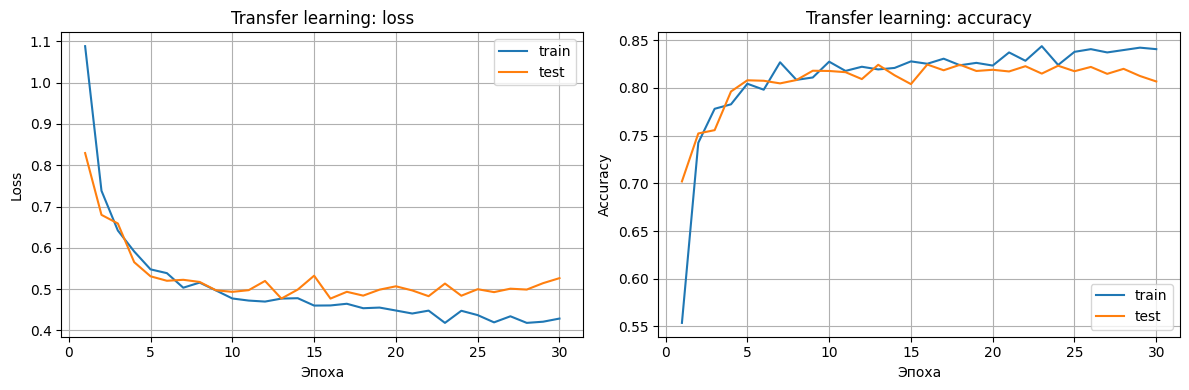

Итоговая точность TL: train=0.8406, test=0.8067


In [32]:
epochs_tl = np.arange(1, num_epochs_tl + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_tl, history_tl["train_loss"], label="train")
plt.plot(epochs_tl, history_tl["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Transfer learning: loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_tl, history_tl["train_acc"], label="train")
plt.plot(epochs_tl, history_tl["test_acc"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Transfer learning: accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Итоговая точность TL: train={history_tl['train_acc'][-1]:.4f}, test={history_tl['test_acc'][-1]:.4f}")

## 9. Итоговые выводы по лабораторной

В заключение сформулируйте короткое резюме (5–8 предложений):
- в каких случаях вы после этой работы **в первую очередь** будете пробовать transfer learning и почему;
- когда, по вашему мнению, имеет смысл всё-таки обучать модель с нуля (и зачем);
- какие настройки (заморозка слоёв, lr, число эпох, размер подвыборки) вы считаете для себя "разумными по умолчанию" после проведённых экспериментов.

Пишите так, чтобы вы сами, открыв этот ноутбук через полгода, смогли быстро вспомнить, что вы поняли про transfer learning.


In [33]:
final_summary = """После этой работы я буду проьовать TL для задач, где есть небольшое количество данных и есть предобученная модель, обученная на похожих изображениях.
  Как можно заметить, после увеличение картинок CIFAR-10 до 224х224, модель показала точность значительно выше, чем при размере 32х32.
  В таких случаях модель быстро выходит на высокую точность и требует обучения только небольшого числа параметров.
  Также transfer learning удобен, когда важно сократить время обучения и вычислительные ресурсы.

Модель стоит обучать с нуля, когда датасет достаточно большой и предобученные признаки плохо подходят для нового датасета.
  В этом случае модель будет лучше адаптироваться к новым признакам, данным, но обучение будет длиться дольше.

По умолчанию я бы сначала замораживала все слои и обучала только классификатор, используя lr около 1e-3 и 10–30 эпох.
  Если качество выходит на плато, имеет смысл разморозить последние слои и уменьшить lr.
  Также важно проверять размер входных изображений и при необходимости приводить его к размеру, на котором обучалась модель.
"""
print(final_summary)

После этой работы я буду проьовать TL для задач, где есть небольшое количество данных и есть предобученная модель, обученная на похожих изображениях.
  Как можно заметить, после увеличение картинок CIFAR-10 до 224х224, модель показала точность значительно выше, чем при размере 32х32.
  В таких случаях модель быстро выходит на высокую точность и требует обучения только небольшого числа параметров. 
  Также transfer learning удобен, когда важно сократить время обучения и вычислительные ресурсы.

Модель стоит обучать с нуля, когда датасет достаточно большой и предобученные признаки плохо подходят для нового датасета.
  В этом случае модель будет лучше адаптироваться к новым признакам, данным, но обучение будет длиться дольше.

По умолчанию я бы сначала замораживала все слои и обучала только классификатор, используя lr около 1e-3 и 10–30 эпох.
  Если качество выходит на плато, имеет смысл разморозить последние слои и уменьшить lr.
  Также важно проверять размер входных изображений и при не